# 02｜位置编码与 Q/K/V：做一次 Attention 手算

Self-Attention 会比较 Query 与每个 Key，再用 Softmax 权重汇总 Value。本页只做机制演示，不训练模型。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "transformer_lab").is_dir():
    LAB_DIR = (LAB_DIR / "04_transformer_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

torch.set_num_threads(1)

from transformer_lab import (
    TinyTransformerClassifier, make_retrieval_data,
    plot_attention_weights, plot_positional_encoding,
    scaled_dot_product_attention,
)


## 为什么需要位置编码？

如果只给 Transformer 颜色 Embedding，它知道“有哪些颜色”，却不知道“哪个颜色在第 0 位”。正弦位置编码给每个位置一组不同、可延伸的数值。

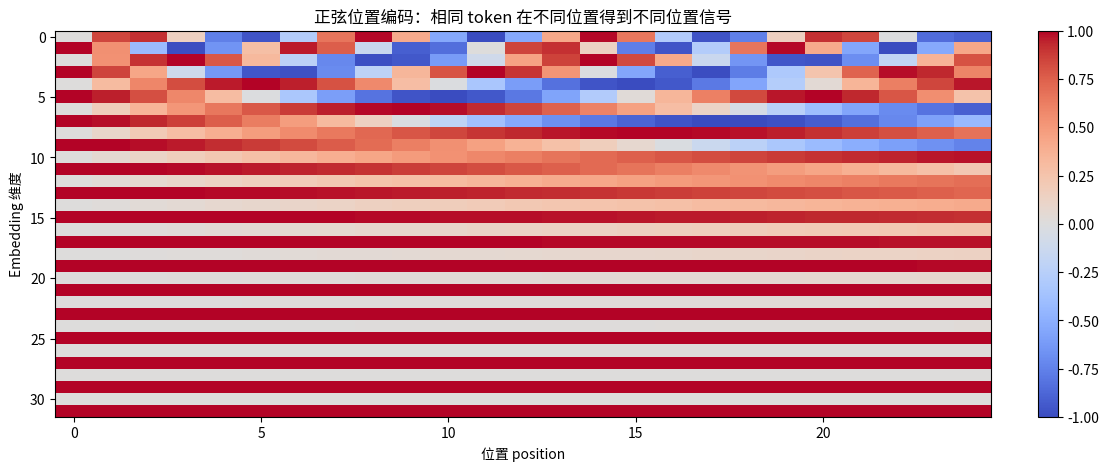

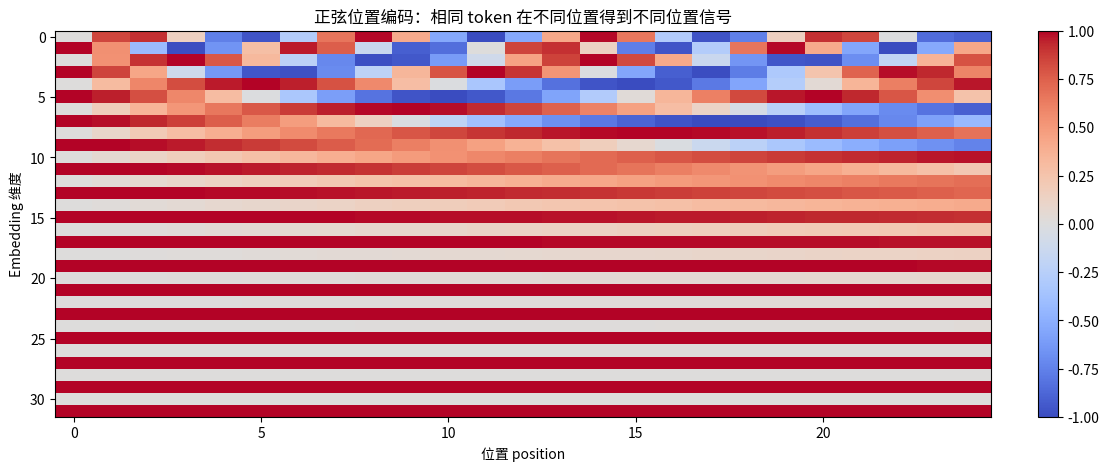

In [2]:
plot_positional_encoding(d_model=32, max_length=25)


## Q、K、V 的直觉

- **Query：**我现在想找什么？
- **Key：**每个位置提供什么检索线索？
- **Value：**如果关注这个位置，要取回什么信息？

一个 Query 的 Scaled Dot-product Attention 为：

\[
s_i=\frac{q\cdot k_i}{\sqrt{d}},\qquad
a_i=\operatorname{softmax}(s)_i,\qquad
o=\sum_i a_i v_i
\]

先凭点积判断哪个 Key 更接近 Query，再运行代码。

缩放前点积： [1.0, 0.0, 0.5]
缩放后 scores： [0.7070000171661377, 0.0, 0.3540000021457672]
Softmax weights： [0.4560000002384186, 0.22499999403953552, 0.3199999928474426]
权重和： 1.0
加权 Value： [1.2309999465942383, 1.218000054359436]


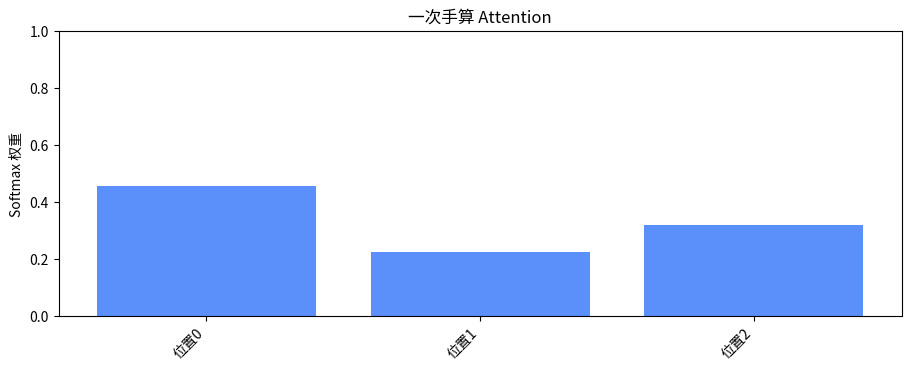

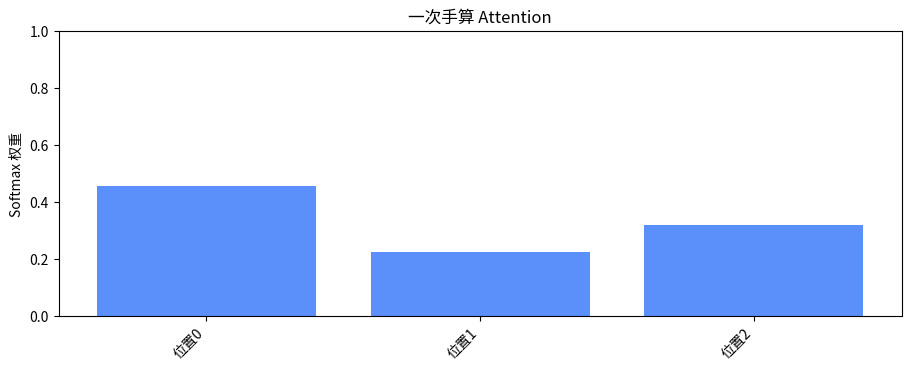

In [3]:
query = torch.tensor([1.0, 0.0])
keys = torch.tensor([
    [1.0, 0.0],   # 位置 0：方向最接近 Query
    [0.0, 1.0],   # 位置 1
    [0.5, 0.5],   # 位置 2
])
values = torch.tensor([
    [2.0, 0.0],
    [0.0, 4.0],
    [1.0, 1.0],
])

scores, weights, output = scaled_dot_product_attention(query, keys, values)
print("缩放前点积：", (keys @ query).tolist())
print("缩放后 scores：", scores.numpy().round(3).tolist())
print("Softmax weights：", weights.numpy().round(3).tolist())
print("权重和：", float(weights.sum()))
print("加权 Value：", output.numpy().round(3).tolist())
plot_attention_weights(weights, labels=["位置0", "位置1", "位置2"], title="一次手算 Attention")


## 从单个 Query 到多头 Self-Attention

实际模型会同时为每个位置计算 Q、K、V，并把维度分给多个 Head。不同 Head 可以形成不同权重，但“更多 Head”不保证更准确。

In [4]:
data = make_retrieval_data(
    content_length=12, train_size=30, val_size=9, test_size=9, seed=42
)
model = TinyTransformerClassifier(
    d_model=16, num_heads=4, num_layers=1,
    dim_feedforward=32, dropout=0.0,
)
logits, attention = model.forward_with_attention(data.x_train[:2])
print("输入 token ids [B,T]：", tuple(data.x_train[:2].shape))
print("Attention [B,Head,T,T]：", tuple(attention.shape))
print("输出 logits [B,3]：", tuple(logits.shape))
print("每一行权重和接近 1：",
      attention.sum(dim=-1)[0, 0, :3].detach().numpy().round(5).tolist())


输入 token ids [B,T]： (2, 13)
Attention [B,Head,T,T]： (2, 4, 13, 13)
输出 logits [B,3]： (2, 3)
每一行权重和接近 1： [1.0, 1.0, 1.0]


## 读图与常见误区

- 位置编码与颜色 Embedding 是相加，不是把位置当成新类别；
- Softmax 权重非负且每行和为 1，但不是分类概率；
- Q/K/V 是线性投影后的表示，不等于原始 token；
- Attention 权重可以作为诊断证据，不能单独证明因果解释。

## 完成本页后：释放资源并结束内核

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)
